<a href="https://colab.research.google.com/github/mirzulqarnain/DEEP_LEARNING_REPS/blob/main/OPTIMIZERS/SGD_Momwntum_NAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

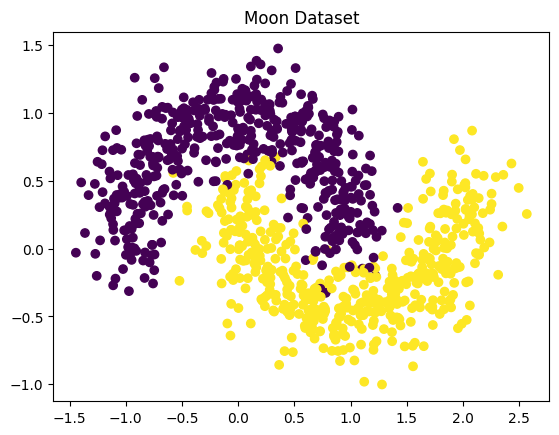

In [2]:
X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y)

plt.title("Moon Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def create_model():

    model = Sequential([
        Dense(10, activation='relu', input_shape=(2,)),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    return model

In [6]:
model_sgd = create_model()

optimizer_sgd = SGD(
    learning_rate=0.01
)

model_sgd.compile(
    optimizer=optimizer_sgd,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_momentum = create_model()

optimizer_momentum = SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_momentum.compile(
    optimizer=optimizer_momentum,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test, y_test)
)

In [8]:
model_nag = create_model()

optimizer_nag = SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model_nag.compile(
    optimizer=optimizer_nag,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_nag = model_nag.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test, y_test)
)

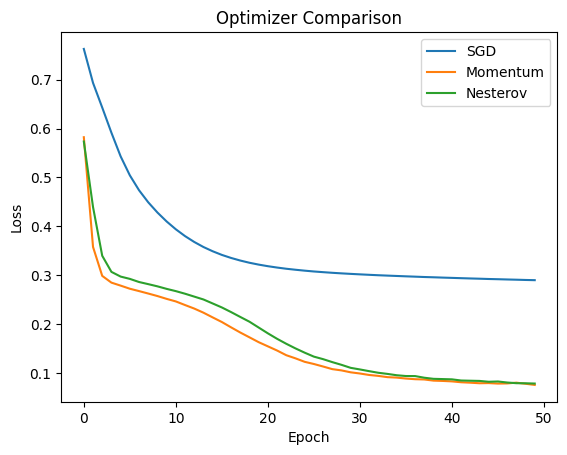

In [9]:
plt.plot(history_sgd.history['loss'], label='SGD')

plt.plot(history_momentum.history['loss'], label='Momentum')

plt.plot(history_nag.history['loss'], label='Nesterov')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()